                r_pol       r_eq
    normal    25000.0    25590.9
     split    25000.0    25590.4


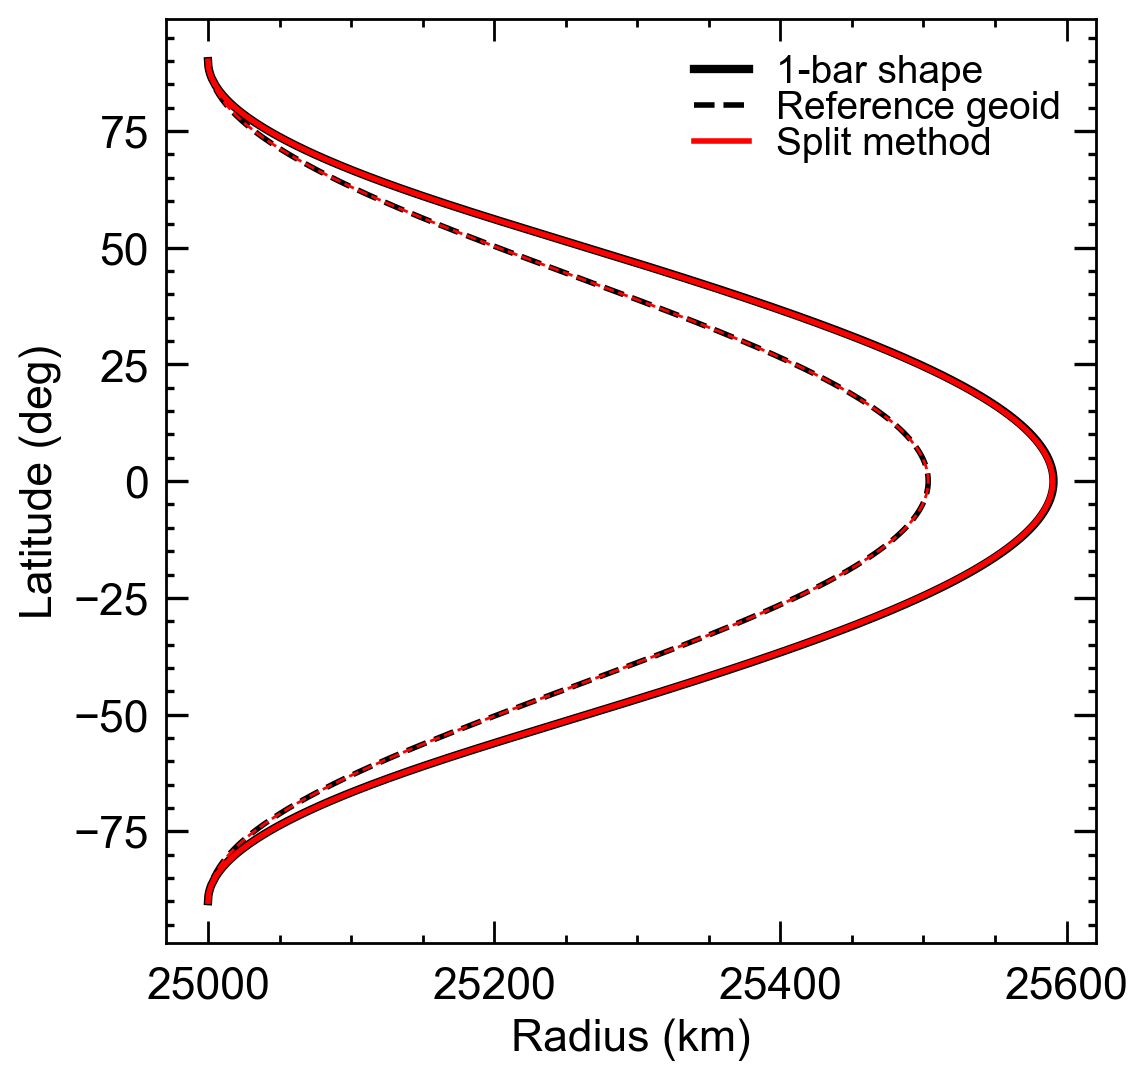

In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# get a callable omega(phi) from observed wind profile, can pass option='symmetric' (default) or option='composite' (an odd profile stitching together Voyager 2 and Keck/Gemini data)
omega = wind_profiles.uranus_omega_tot_interpolant()

# constants for Uranus; French et al. (2024 Icarus) Table 17, Fit 15 (Adopted solution)
r_ref = 25559e5
jn = 3509.291e-6, -35.522e-6, 0.
gm = 5793950.3e15

# fix the polar radius and solve for the shape
r_pol = 25000e5
print(f"{'':>10} {'r_pol':>10} {'r_eq':>10}")
# preferred (slower) method: retain full rotation
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation
g0 = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(17.25*3600)) # pass constant "bulk" rotation to construct a rigidly rotating reference geoid
print(f'{"normal":>10} {1e-5*r_pol:10.1f} {1e-5*g.r[len(g.mu) // 2]:10.1f}')
plt.plot(1e-5 * g.r, g.lat, 'k-', lw=3, label='1-bar shape')
plt.plot(1e-5 * g0.r, g0.lat, 'k--', lw=2, label='Reference geoid')

# split method: shape gets contributions from rigid and differential rotation parts; calculate reference geoid and dynamical height separately
g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=np.pi*2/(17.25*3600), omega=omega) # alternate method
print(f'{"split":>10} {1e-5*r_pol:10.1f} {1e-5*g.r[len(g.mu) // 2]:10.1f}')
plt.plot(1e-5 * g.r, g.lat, color='r', label='Split method')
plt.plot(1e-5 * g.r_geoid, g.lat, '--', color='r', lw=1)

plt.xlabel(r'Radius (km)')
plt.ylabel(r'Latitude (deg)')
plt.legend(fontsize=14)

    period      r_pol       r_eq     h_mean  pole-pole 
     15.25    25000.0    25590.6        3.4   0.00e+00
     16.25    25000.0    25590.7       32.3   0.00e+00
     17.25    25000.0    25590.4       55.9   0.00e+00
     18.25    25000.0    25589.8       75.5   0.00e+00


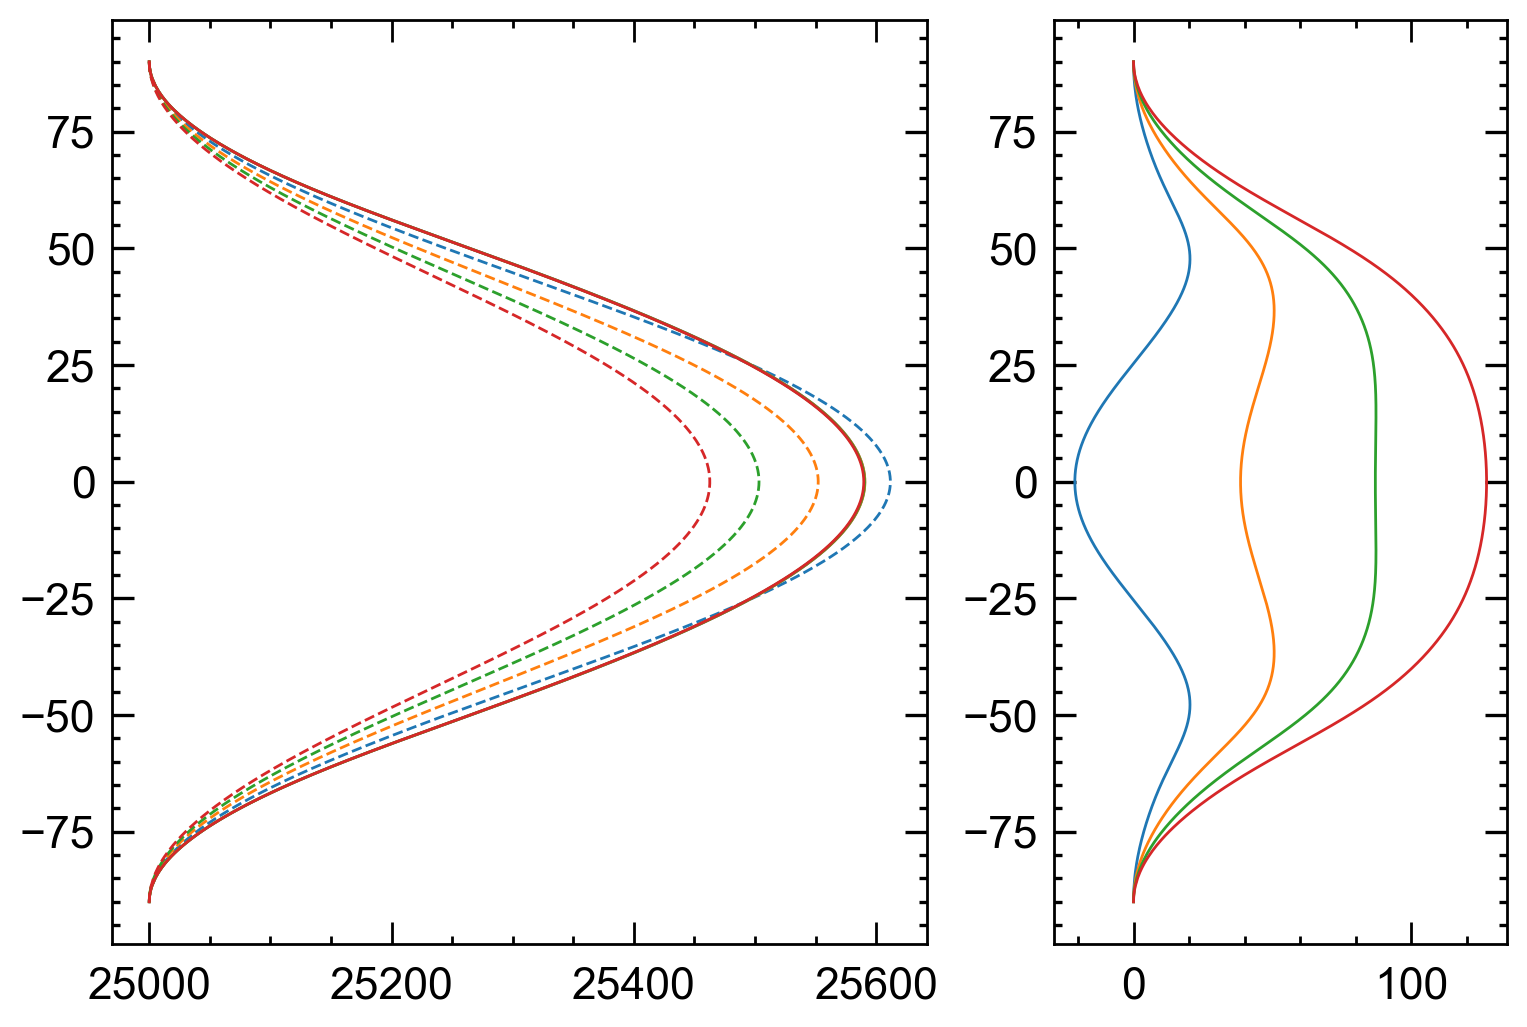

In [2]:
# for split (Lindal) method, different background rotation may yield slightly different shapes, but this is a byproduct of the numerical construction.
# including any conversion between angular velocity and linear velocity can introduce discrepancies, because such a conversion involves
# the distance to the rotation axis. this distance is dependent on the shape of the reference geoid, which can be different from that of the final model.

# now that the total rotation profile is specified, the overall error (here in r_eq) is down to a few hundred meters over the 3-hour range of rotation periods considered.
# in previous versions where we were involving even more conversions from angular angular to linear velocity, this error was around 6 km.
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'pole-pole':>10} ")
fig, ax = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios':(9,5)})
periods = 15.25, 16.25, 17.25, 18.25 # 3-hour range
for ip, p_rot_h in enumerate(periods):
    omega_rigid = np.pi*2/(p_rot_h*3600)
    g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

    r_eq = g.r[len(g.mu) // 2]
    pole_to_pole = g.r[-1] - g.r[0] # should be zero if integration is accurate and wind profile is north-south symmetric
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * g.h_mean:10.1f} {1e-5*pole_to_pole:10.2e}')

    ax[0].plot(1e-5 * g.r_geoid, g.lat, '--', color=f'C{ip}', lw=1)
    ax[0].plot(1e-5 * g.r, g.lat, '-', color=f'C{ip}', lw=1)
    ax[1].plot(1e-5 * g.h, g.lat, '-', color=f'C{ip}', lw=1)

# the integral version that retains the full latitude-dependent Omega (as in Galanti et al. 2023 GRL) shows that r_pol is uniquely specified by the equatorial (or any) radius.

In [3]:
occultation_radii = {'voyager 2 ingress': (-2.9, 25555.3), 'voyager 2 egress': (-6.6, 25550.8)} # Lindal et al. 1987
# occultation_radii = {'voyager 2 ingress': (-2.9, 25556.7), 'voyager 2 egress': (-6.6, 25550.7)} # Caruso et al.'s 2025 AGU poster

rmse = 0.5 km
    period      r_pol r_eq_geoid       r_eq     h_mean
     15.25    24968.4  25577.845  25557.116       3.42
     16.25    24968.4  25518.616  25557.116      32.21
     17.25    24968.4  25470.017  25557.116      55.91
     18.25    24968.4  25429.619  25557.116      75.66


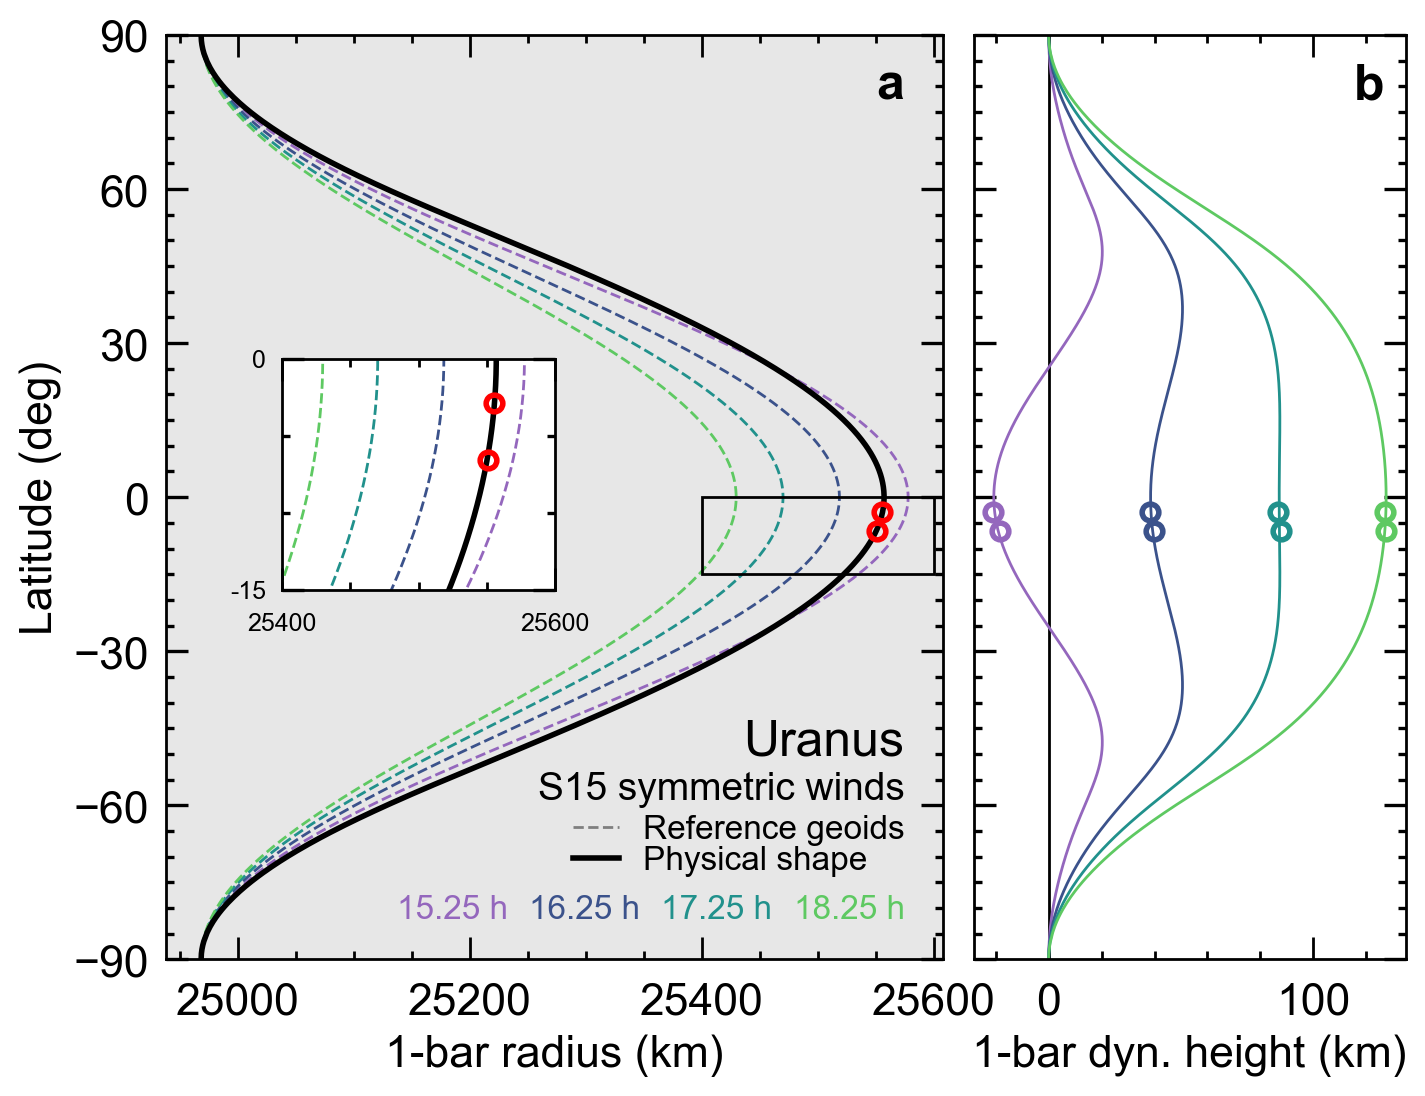

In [32]:
# main shape model plot for paper
from matplotlib.patches import Rectangle
def shape_plot(skip_inset_eq=False, inset_xlim=(25400, 25600)):    
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        inset_xlim = inset_xlim
        ax_inset_eq = ax[0].inset_axes([0.15, 0.4, 0.35, 0.25], xlim=inset_xlim, ylim=(-15, 0), xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], -15), inset_xlim[1]-inset_xlim[0], 15, facecolor='none', edgecolor='k', lw=1, zorder=2))
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], 5)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks([-15, -10, -5, 0], minor=True)
        ax_inset_eq.set_yticks([-15, 0], [-15, 0], minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    # ax[0].set_xlabel('100-mbar radius (km)')
    # ax[1].set_xlabel('100-mbar dyn. height (km)')
    ax[0].set_xlabel('1-bar radius (km)')
    ax[1].set_xlabel('1-bar dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()

reload(geoid)
from scipy.optimize import minimize_scalar

if False: # fit just point closest to the equator
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 ingress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')
else: # find r_pol that minimizes rms radius error of both occultations
    def get_rmse(x):
        r_pol = x * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    print(f'rmse = {sol.fun:.1f} km')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# reference geoids depend on rigid rotation; loop through them now
print(f"{'period':>10} {'r_pol':>10} {'r_eq_geoid':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    r_eq_ref = g_ref.r[len(g_ref.mu) // 2]
    
    color = 'tab:purple' if ip == 0 else plt.get_cmap()(1. * (ip) / 4)

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.44 + 0.17 * ip, 0.07, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq_ref:10.3f} {1e-5*r_eq:10.3f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoids')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.057), fontsize=12)
ax[0].text(0.95, 0.21, 'Uranus', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.165, 'S15 symmetric winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

import copy
g_baseline = copy.deepcopy(g) # store main shape model to write to disk later

plt.savefig('figures/uranus_optimize_rpol.pdf')
plt.savefig('figures/uranus_optimize_rpol.png')

    # period      r_pol r_eq_geoid       r_eq     h_mean
    #  15.25    24968.4  25577.845  25557.116       3.42
    #  16.25    24968.4  25518.616  25557.116      32.21
    #  17.25    24968.4  25470.017  25557.116      55.91
    #  18.25    24968.4  25429.619  25557.116      75.66


    period      r_pol       r_eq     h_mean  pole-pole       rmse
     15.25    24968.7    25557.1        3.3   0.00e+00        0.5
     16.25    24968.6    25557.1       32.1   0.00e+00        0.5
     17.25    24968.9    25557.1       55.6   0.00e+00        0.5
     18.25    24969.4    25557.1       75.1   0.00e+00        0.5


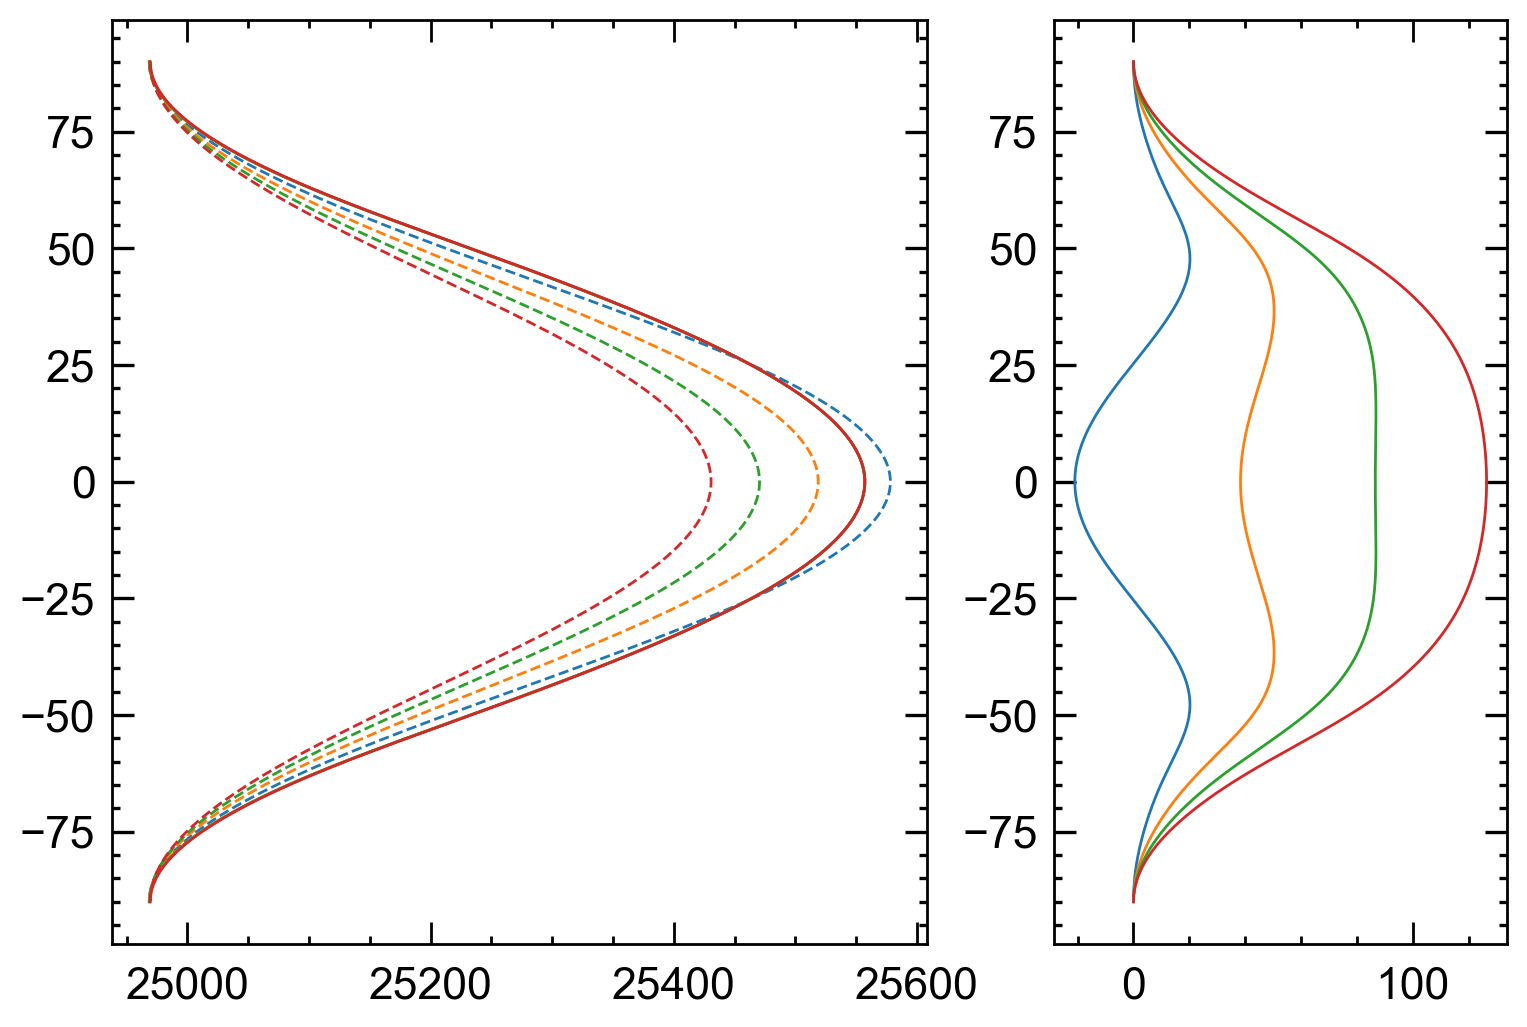

In [33]:
# for comparison with main result, do optimization to occultation using split method
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'pole-pole':>10} {'rmse':>10}")
fig, ax = plt.subplots(1, 2, figsize=(9, 6), gridspec_kw={'width_ratios':(9,5)})
for ip, p_rot_h in enumerate(periods):
    omega_rigid = np.pi*2/(p_rot_h*3600)

    if False: # fit near-equatorial point
        r_pol = 25000e5
        for i in range(10):
            # geoid_split() takes both omega_rigid (the uniform spin of the reference geoid) and omega (a callable giving the full atmospheric rotation, omega(phi))
            g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

            # compare to data and adjust r_pol
            latitude, radius = occultation_radii['voyager 2 ingress']
            error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
            # print(i, r_pol, error_km)
            if abs(error_km) < 0.001: break
            r_pol += 1e5 * error_km
        else:
            raise RuntimeError('failed in iterations to fit occultations')
    else: # fit rms error
        from scipy.optimize import minimize
        def get_rmse(x):
            r_pol = x * 1e9
            # geoid_split() takes both omega_rigid (the uniform spin of the reference geoid) and omega (a callable giving the full atmospheric rotation, omega(phi))
            g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega) 
            squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
            return np.sqrt(np.mean(squared_errors))
        sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
        r_pol = sol.x * 1e9

        # get final shape for optimized r_pol
        g = geoid.geoid_split(r_pol, jn, r_ref, gm, omega_rigid=omega_rigid, omega=omega)

    r_eq = g.r[len(g.mu) // 2]
    pole_to_pole = g.r[-1] - g.r[0] # should be zero if integration is accurate and wind profile is north-south symmetric
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * g.h_mean:10.1f} {1e-5*pole_to_pole:10.2e} {sol.fun:10.1f}')

    ax[0].plot(1e-5 * g.r_geoid, g.lat, '--', color=f'C{ip}', lw=1)
    ax[0].plot(1e-5 * g.r, g.lat, '-', color=f'C{ip}', lw=1)
    ax[1].plot(1e-5 * g.h, g.lat, '-', color=f'C{ip}', lw=1)

    # period      r_pol       r_eq     h_mean  pole-pole       rmse
    #  15.25    24968.7    25557.1        3.3   0.00e+00        0.5
    #  16.25    24968.6    25557.1       32.1   0.00e+00        0.5
    #  17.25    24968.9    25557.1       55.6   0.00e+00        0.5
    #  18.25    24969.4    25557.1       75.1   0.00e+00        0.5


    period      r_pol       r_eq     h_mean    ell_vol   rmse_ref   rmse_act
     15.25    24950.0    25537.4       3.41  6.816e+28        1.2       19.7
     16.25    25005.1    25596.4      32.40  6.862e+28        0.8       39.2
     17.25    25051.1    25645.5      56.68  6.901e+28        0.6       88.4
     18.25    25089.9    25687.0      77.21  6.934e+28        0.3      129.8


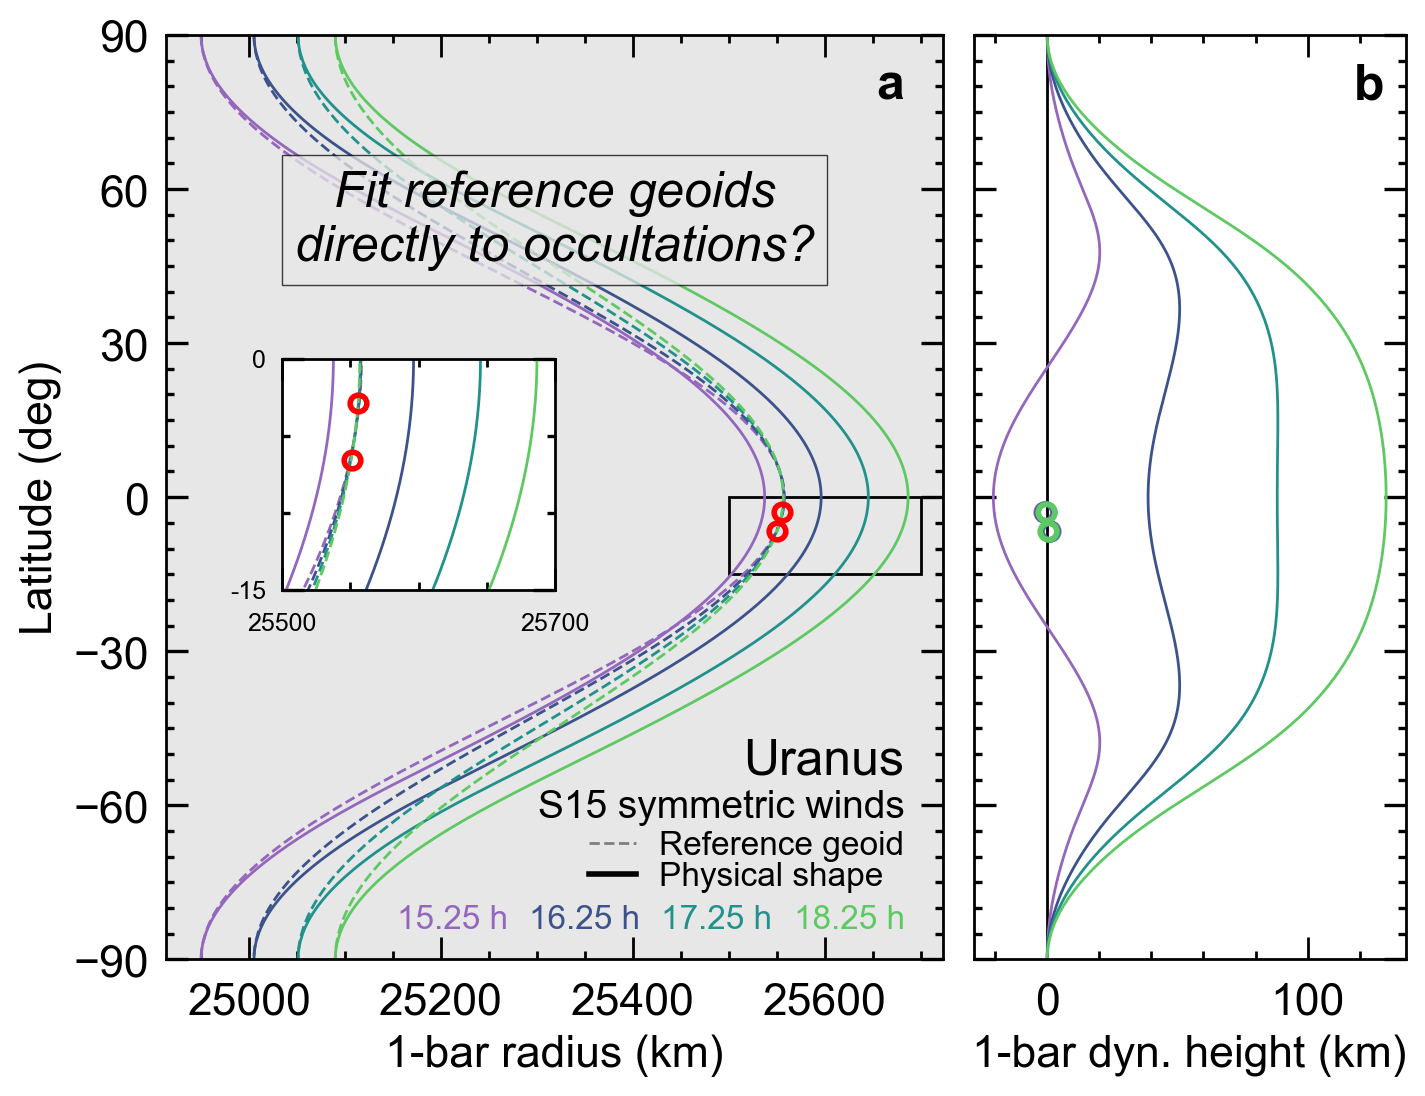

In [34]:
# here incorrectly fit the rigidly rotating *reference geoids* to the occultations instead

ax, ax_inset = shape_plot(inset_xlim=(25500, 25700))

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10} {'ell_vol':>10} {'rmse_ref':>10} {'rmse_act':>10}")

for ip, p_rot_h in enumerate(periods):
    if False: # fit only the near-equatorial point
        r_pol = 25000e5
        for i in range(10):
            g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))

            # compare to data and adjust r_pol
            latitude, radius = occultation_radii['voyager 2 ingress']
            error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g_ref.r[::-1])
            if abs(error_km) < 0.001: break
            r_pol += 1e5 * error_km
        else:
            raise RuntimeError('failed in iterations to fit occultations')
    else: # fit rms error for two occultations
        def get_rmse(x):
            r_pol = x * 1e9
            g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600)) # rigidly rotating reference geoid
            squared_errors = np.array([ (_r - np.interp(_lat, g_ref.lat[::-1], 1e-5 * g_ref.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
            return np.sqrt(np.mean(squared_errors))
        sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
        rmse = sol.fun
        # print(f'rmse = {sol.fun:.1f} km')
        r_pol = sol.x * 1e9
        g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600)) # final reference geoid for best-fitting r_pol

    # full isobaric shape, including the effect of the winds, for this same polar radius
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]

    # get actual rmse error relative to the physical isobaric surface -- it will be large
    rmse_act = np.sqrt(np.mean(np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])))

    color = 'tab:purple' if ip == 0 else plt.get_cmap()(1. * (ip) / 4)

    ax[0].plot(1e-5 * g.r, g.lat, '-', color=color, lw=1)
    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)
    ax_inset.plot(1e-5 * g.r, g.lat, '-', color=color, lw=1)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    # volume enclosed by this isobar in the ellipsoidal approximation
    volume = 4. * np.pi / 3 * r_eq ** 2 * r_pol

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.44 + 0.17 * ip, 0.06, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f} {volume:10.3e} {rmse:10.1f} {rmse_act:10.1f}')

for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.04), fontsize=12)
ax[0].text(0.95, 0.19, 'Uranus', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.145, 'S15 symmetric winds', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)

fig = plt.gcf()
ax[0].text(0.5, 0.8, 'Fit reference geoids\ndirectly to occultations?', ha='center', va='center', fontsize=18, transform=ax[0].transAxes, style='italic')
xc, yc = 0.5, 0.8
xw, yw = 0.7, 0.14
yb = yc - yw / 2
xl = xc - xw / 2
ax[0].add_artist(Rectangle((xl, yb), xw, yw, facecolor='#e7e7e7', edgecolor='k', lw=0.5, zorder=2, alpha=0.75, transform=ax[0].transAxes))

for iax, c in enumerate('ab'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/uranus_optimize_rpol_ignore_winds.pdf')

    # period      r_pol       r_eq     h_mean    ell_vol   rmse_ref   rmse_act
    #  15.25    24950.0    25537.4       3.41  6.816e+28        1.2       19.7
    #  16.25    25005.1    25596.3      32.40  6.862e+28        0.8       39.2
    #  17.25    25051.1    25645.5      56.68  6.901e+28        0.6       88.4
    #  18.25    25089.9    25687.0      77.21  6.934e+28        0.3      129.8


In [35]:
''' minimize the dynamical height as a function of Omega_0 '''

reload(geoid)
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")

if False: # fit only near-equatorial point
    r_pol = 25000e5
    for i in range(10):
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation

        # compare to data and adjust r_pol
        latitude, radius = occultation_radii['voyager 2 ingress']
        error_km = radius - np.interp(latitude, g.lat[::-1], 1e-5 * g.r[::-1])
        if abs(error_km) < 0.001: break
        r_pol += 1e5 * error_km
    else:
        raise RuntimeError('failed in iterations to fit occultations')
else: # fit rmse of two occultations
    from scipy.optimize import minimize
    def get_rmse(x):
        r_pol = x * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    print(f'rmse = {sol.fun:.1f} km')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

# solve for the reference geoid rotation period that minimizes the dynamical height
def zero_me(p_rot_h):
    g_ref = geoid.geoid(g.r[0], jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)
    print(f'{p_rot_h[0]:10.2f} {1e-5 * r_pol:10.2f} {1e-5 * r_eq:10.2f} {1e-5 * h_mean:10.2f}')
    return h_mean

from scipy.optimize import root
sol = root(zero_me, 17.25)
print(sol)
print(sol.x[0]) # 15.14 h


    period      r_pol       r_eq     h_mean
rmse = 0.5 km
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     17.25   24968.44   25687.01      55.91
     14.66   24968.44   25687.01     -16.66
     15.25   24968.44   25687.01       3.51
     15.15   24968.44   25687.01       0.18
     15.14   24968.44   25687.01      -0.00
     15.14   24968.44   25687.01       0.00
     15.14   24968.44   25687.01       0.00
 message: The solution converged.
 success: True
  status: 1
     fun: 3.043562173843384e-07
       x: [ 1.514e+01]
  method: hybr
    nfev: 10
    fjac: [[-1.000e+00]]
       r: [-3.253e+06]
     qtf: [-1.205e-01]
15.143789659174853


In [36]:
# selecting a workable tolerance for solve_ivp.
reload(geoid)
import time
for tol in 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6:
    t0 = time.time()
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega, solve_ivp_tol=tol)
    print(tol, 1e-5 * g.r[len(g.mu) // 2], time.time() - t0)

# at 1e-8, a factor of a few faster and still accurate to about 5 m.
# however, testing below for randomized rotation profiles shows that the optimization of r_pol to r_occ can fail to converge with looser tolerances on solve_ivp integration.
# hence, we'll stick to the 1e-10 tolerances.

1e-11 25557.116133905638 1.4249169826507568
1e-10 25557.116134281725 0.01247715950012207
1e-09 25557.115916675735 0.007214069366455078
1e-08 25557.11211383201 0.004921913146972656
1e-07 25557.102595626155 0.0033528804779052734
1e-06 25557.32827145796 0.002312898635864258


In [37]:
# below is uncertainty quantification, doing some tens of thousands of models with input parameters (wind profiles, occultation radii, gravity moments) drawn from statistical distributions.
# this somewhat time-consuming (run time of about an hour on my m2 macbook) so it can be handy to save the full output (as pickled python dictionary organizing many geoid.geoid objects).
# here, if we've already run the below cells and saved the bulky (6 GB) pickle, we can load that instead of repeating the runs:

if False:
    # import dill as pickle
    import pickle
    with open('models/geoid_objects/uranus.pkl', 'rb') as fw:
        uranus_models = pickle.load(fw)
    models_vary_wind = uranus_models['vary_wind']
    models_vary_ro = uranus_models['vary_ro']
    models_vary_jn = uranus_models['vary_jn']

# then just skip the cells that would overwrite models_vary_wind, etc. these cells are the ones with with functions like solve_one(), etc.

In [38]:
occultation_radii

{'voyager 2 ingress': (-2.9, 25555.3), 'voyager 2 egress': (-6.6, 25550.8)}

In [ ]:
''' quantifying uncertainties in the shape as a function of those in occultation radii, gravity field, rotation profile '''

reload(geoid)
reload(wind_profiles)
from scipy.optimize import minimize
np.random.seed(2025)

# do the faster split calculation since we are running many models? factor of 10 faster. 
# trying this here, the mean polar radius shifts downward by 0.3 km, similar to the standard deviation, so we'll stick to the full calculation.

# how much scatter in uranus's polar radius as a function of the uncertain wind profile?
def solve_one(wind_option, randomize=False):
    omega = wind_profiles.uranus_omega_tot_interpolant(option=wind_option, randomize=randomize) # the answer will depend on which wind option, though

    def get_rmse(x):
        r_pol = x * 1e9
        g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
        squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
        return np.sqrt(np.mean(squared_errors))
    sol = minimize_scalar(get_rmse, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    assert sol.success, 'failed to fit occultations'
    # print(sol.nit, sol.nfev, f'{sol.fun:.1f}')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

    return g

from tqdm import tqdm
models_vary_wind = {}

models_vary_wind['composite'] = solve_one('composite')

# nmodels = 10 # testing
nmodels = 1000
models_vary_wind['symmetric'] = {}
for i in tqdm(np.arange(nmodels)):
    models_vary_wind['symmetric'][i] = solve_one('symmetric', randomize=True)


100%|██████████| 1000/1000 [07:22<00:00,  2.26it/s]


symmetric profile: $24968.4\pm0.4$ km


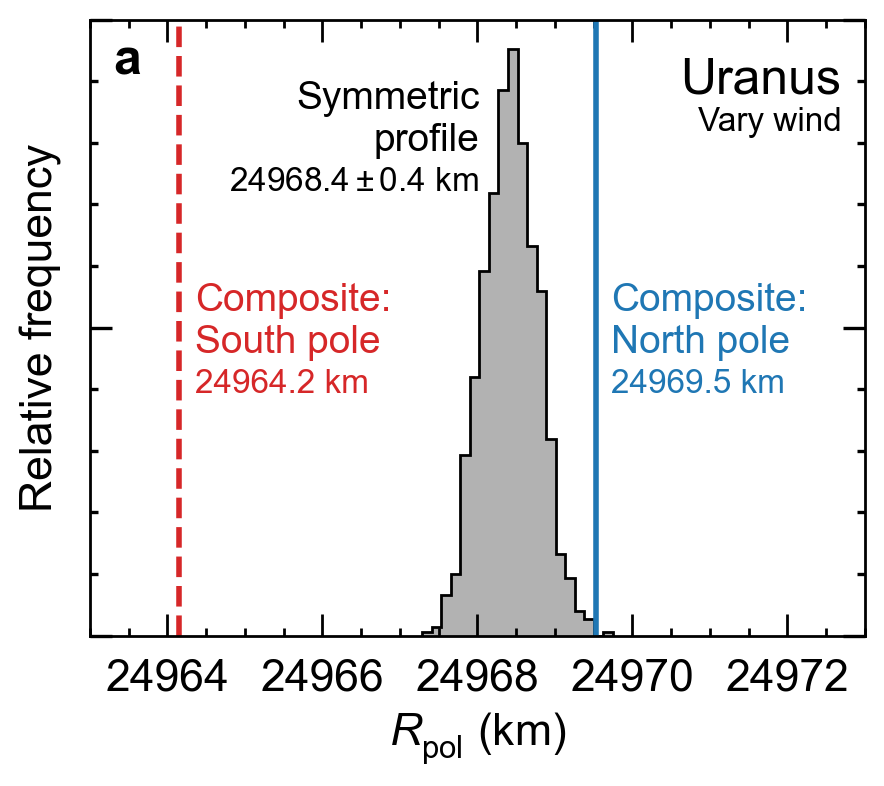

In [ ]:
offset = 0
plt.figure(figsize=(5, 4))
rp = np.array([g.r[0] for seed, g in models_vary_wind['symmetric'].items()])
plt.hist(1e-5 * rp - offset, alpha=0.3, density=True, color='k', bins=20)
plt.hist(1e-5 * rp - offset, density=True, color='k', bins=20, histtype='step')
stats = rf'${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km'
print('symmetric profile:', stats)
plt.text(np.mean(rp*1e-5) - 0.4, 1.1, 'Symmetric\nprofile', ha='right', va='top', color='k', fontsize=14)
plt.text(np.mean(rp*1e-5) - 0.4, 0.93, stats, ha='right', va='top', color='k', fontsize=12)

yl = np.array(plt.ylim())
# yl[1] *= 1.2
plt.vlines(1e-5 * models_vary_wind['composite'].r[0] - offset, yl[0], yl[1], color='tab:blue', linestyle='-', label='composite profile: North pole')
plt.vlines(1e-5 * models_vary_wind['composite'].r[-1] - offset, yl[0], yl[1], color='tab:red', linestyle='--', label='composite profile: South pole')

plt.text(1e-5 * models_vary_wind['composite'].r[0]  + 0.2, 0.7, 'Composite:\nNorth pole', ha='left', va='top', color='tab:blue', fontsize=14)
plt.text(1e-5 * models_vary_wind['composite'].r[-1] + 0.2, 0.7, 'Composite:\nSouth pole', ha='left', va='top', color='tab:red', fontsize=14)
plt.text(1e-5 * models_vary_wind['composite'].r[0]  + 0.2, 0.53, f"{1e-5 * models_vary_wind['composite'].r[0]:.1f} km", ha='left', va='top', color='tab:blue', fontsize=12)
plt.text(1e-5 * models_vary_wind['composite'].r[-1] + 0.2, 0.53, f"{1e-5 * models_vary_wind['composite'].r[-1]:.1f} km", ha='left', va='top', color='tab:red', fontsize=12)

# plt.legend(fontsize=12, frameon=True)
# plt.xlabel(r'$R_{\rm pol}$ (km) - 24,970 km')
plt.ylim(*yl)
plt.xlabel(r'$R_{\rm pol}$ (km)')
plt.ylabel(r'Relative frequency')
ax = plt.gca()
ax.yaxis.set_ticks([0, yl[1] / 2, yl[1]], minor=False)
ax.yaxis.set_ticks(np.linspace(0, yl[1], 11), minor=True)
ax.tick_params(labelleft=False)
plt.xlim(24963, 24973)
ax.text(0.97, 0.88, 'Uranus',   fontsize=18, ha='right', transform=ax.transAxes)
ax.text(0.97, 0.82, r'Vary wind',fontsize=12, ha='right', transform=ax.transAxes)
ax.text(0.03, 0.97, 'a', weight='bold', fontsize=18, ha='left', va='top', transform=ax.transAxes)
# plt.title('Vary wind profile')
plt.savefig('figures/uranus_polar_radii_histogram.pdf')


# default method:
# symmetric profile: $24968.7\pm0.4$ km

# split method:
# symmetric profile: $24968.4\pm0.3$ km

# since switching to rmse fit:
# symmetric profile: $24968.4\pm0.4$ km


In [44]:
list(models_vary_ro['composite'])

[np.int64(0)]

In [117]:
# how much scatter in uranus's polar and equatorial radius as a function of the RO radius uncertainty?
reload(wind_profiles)

from scipy.stats import norm
omega_symmetric = wind_profiles.uranus_omega_tot_interpolant(option='symmetric')
omega_composite = wind_profiles.uranus_omega_tot_interpolant(option='composite')

def get_rmse_randomize_rocc(x, omega):
    r_pol = x * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    rocc_centroid = np.array([_r for occ, (_lat, _r) in occultation_radii.items()])
    rocc = norm(loc=rocc_centroid, scale=5.).rvs() # occultation radii in km with sigma=5km Gaussian noise added
    lat = np.array([_lat for occ, (_lat, _r) in occultation_radii.items()])
    squared_errors = np.array([ (_rocc - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for _rocc, _lat in zip(rocc, lat)])
    return np.sqrt(np.mean(squared_errors))
    
def solve_one_vary_ro(omega):
    sol = minimize_scalar(get_rmse_randomize_rocc, args=omega, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
    assert sol.success, 'failed to fit occultations'
    # print(sol.nit, sol.nfev, f'{sol.fun:.1f}')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

    return g

np.random.seed(seed=2025)
from tqdm import tqdm

# nmodels = 20
# nmodels = 1000
nmodels = 10000

models_vary_ro = {}
models_vary_ro['symmetric'] = {}
for i in tqdm(np.arange(nmodels)):
    models_vary_ro['symmetric'][i] = solve_one_vary_ro(omega_symmetric)

models_vary_ro['composite'] = {}
for i in tqdm(np.arange(nmodels)):
    models_vary_ro['composite'][i] = solve_one_vary_ro(omega_composite)

100%|██████████| 10000/10000 [2:09:52<00:00,  1.28it/s] 


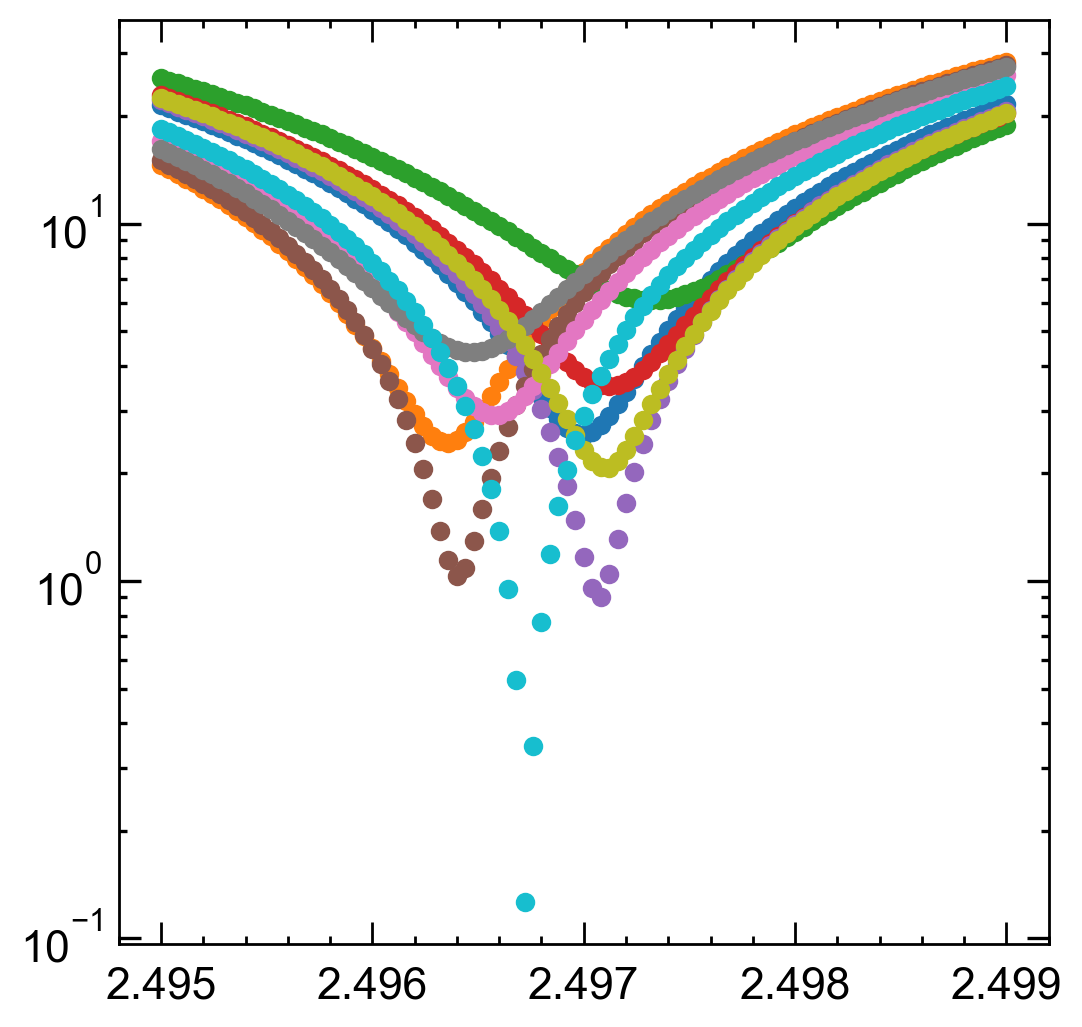

In [ ]:
# why are the radius distributions coming out bimodal?
# does this follow from switching to fitting rmse of two occs, rather than fitting one on the nose?

def _get_rmse(x, omega, rocc):
    r_pol = x * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    lat = np.array([_lat for occ, (_lat, _r) in occultation_radii.items()])
    squared_errors = np.array([ (_rocc - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for _rocc, _lat in zip(rocc, lat)])
    return np.sqrt(np.mean(squared_errors))
    
# def _solve_one_vary_ro(omega):
#     sol = minimize_scalar(get_rmse_randomize_rocc, args=omega, bracket=np.array([2, 3]), method='brent', options={'xtol':1e-6})
#     assert sol.success, 'failed to fit occultations'
#     # print(sol.nit, sol.nfev, f'{sol.fun:.1f}')
#     r_pol = sol.x * 1e9

#     # get final shape for optimized r_pol
#     g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

#     return g

np.random.seed(2025)
for i in range(10):
    # rocc = np.array([_r for occ, (_lat, _r) in occultation_radii.items()])

    rocc_centroid = np.array([_r for occ, (_lat, _r) in occultation_radii.items()])
    rocc = norm(loc=rocc_centroid, scale=5.).rvs() # occultation radii in km with sigma=5km Gaussian noise added

    for x in np.linspace(2.495, 2.499, 101):
        plt.semilogy(x, _get_rmse(x, omega_symmetric, rocc), 'o', color=f'C{i}')

(array([1.000e+00, 6.000e+00, 8.000e+00, 2.800e+01, 5.300e+01, 6.900e+01,
        1.180e+02, 1.820e+02, 3.330e+02, 5.340e+02, 8.050e+02, 1.040e+03,
        1.288e+03, 1.329e+03, 1.150e+03, 9.470e+02, 6.090e+02, 3.640e+02,
        2.220e+02, 1.190e+02, 1.650e+02, 2.180e+02, 2.160e+02, 1.290e+02,
        3.300e+01, 1.400e+01, 7.000e+00, 7.000e+00, 4.000e+00, 2.000e+00]),
 array([2.55412417e+09, 2.55424921e+09, 2.55437425e+09, 2.55449929e+09,
        2.55462433e+09, 2.55474937e+09, 2.55487442e+09, 2.55499946e+09,
        2.55512450e+09, 2.55524954e+09, 2.55537458e+09, 2.55549962e+09,
        2.55562467e+09, 2.55574971e+09, 2.55587475e+09, 2.55599979e+09,
        2.55612483e+09, 2.55624987e+09, 2.55637492e+09, 2.55649996e+09,
        2.55662500e+09, 2.55675004e+09, 2.55687508e+09, 2.55700012e+09,
        2.55712516e+09, 2.55725021e+09, 2.55737525e+09, 2.55750029e+09,
        2.55762533e+09, 2.55775037e+09, 2.55787541e+09]),
 <BarContainer object of 30 artists>)

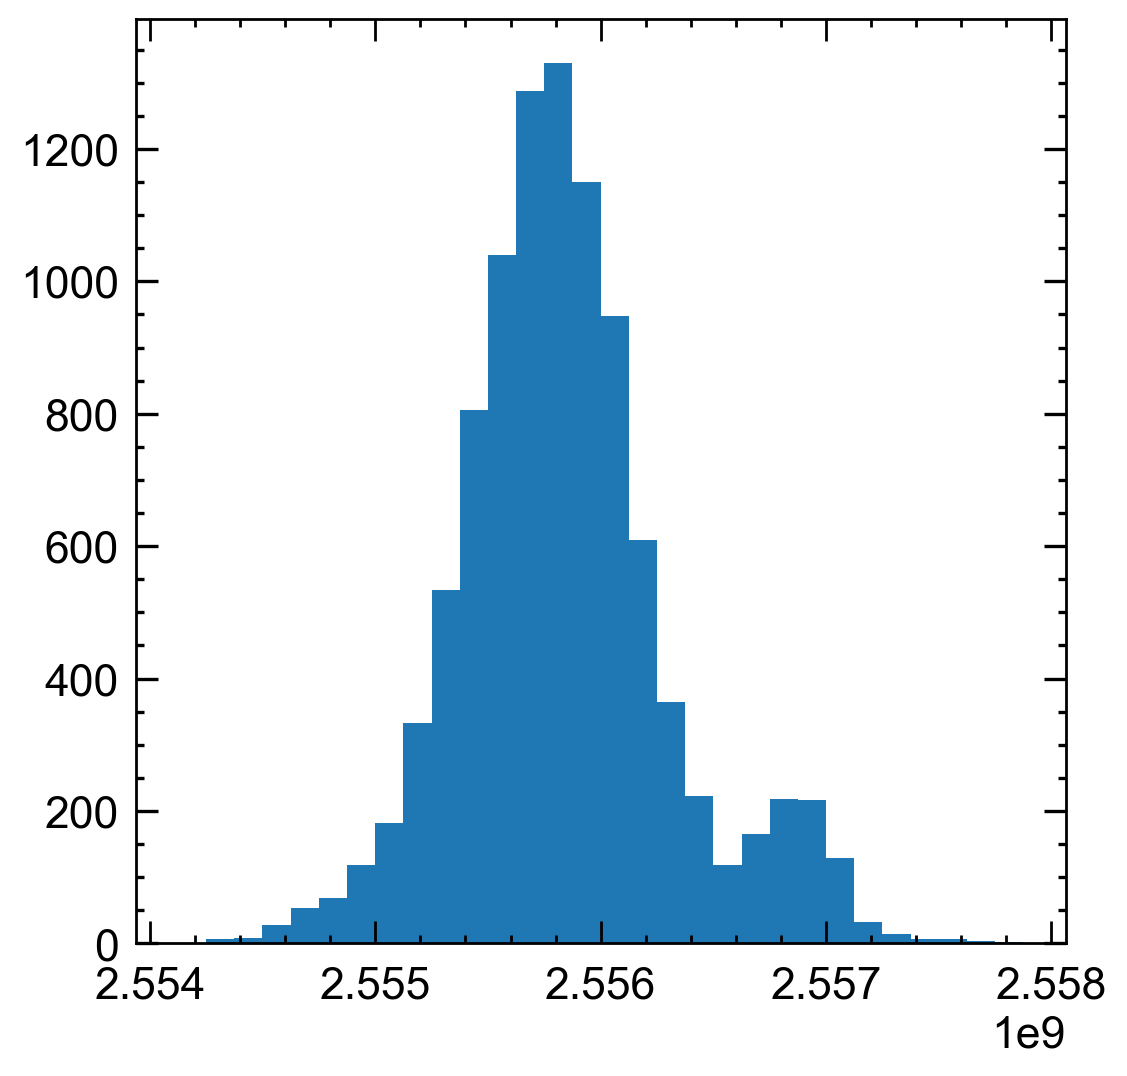

In [ ]:
rp = np.array([g.r[0] for i, g in models_vary_ro['symmetric'].items()])
re = np.array([g.r[len(g.r) // 2] for i, g in models_vary_ro['symmetric'].items()])
plt.hist(re, bins=30)

(array([   9.,   22.,   72.,  140.,  296.,  611., 1185., 1713., 1802.,
        1517.,  910.,  510.,  298.,  434.,  364.,   89.,   16.,    7.,
           3.,    2.]),
 array([2.49501165e+09, 2.49518786e+09, 2.49536408e+09, 2.49554030e+09,
        2.49571652e+09, 2.49589273e+09, 2.49606895e+09, 2.49624517e+09,
        2.49642139e+09, 2.49659760e+09, 2.49677382e+09, 2.49695004e+09,
        2.49712626e+09, 2.49730247e+09, 2.49747869e+09, 2.49765491e+09,
        2.49783113e+09, 2.49800735e+09, 2.49818356e+09, 2.49835978e+09,
        2.49853600e+09]),
 <BarContainer object of 20 artists>)

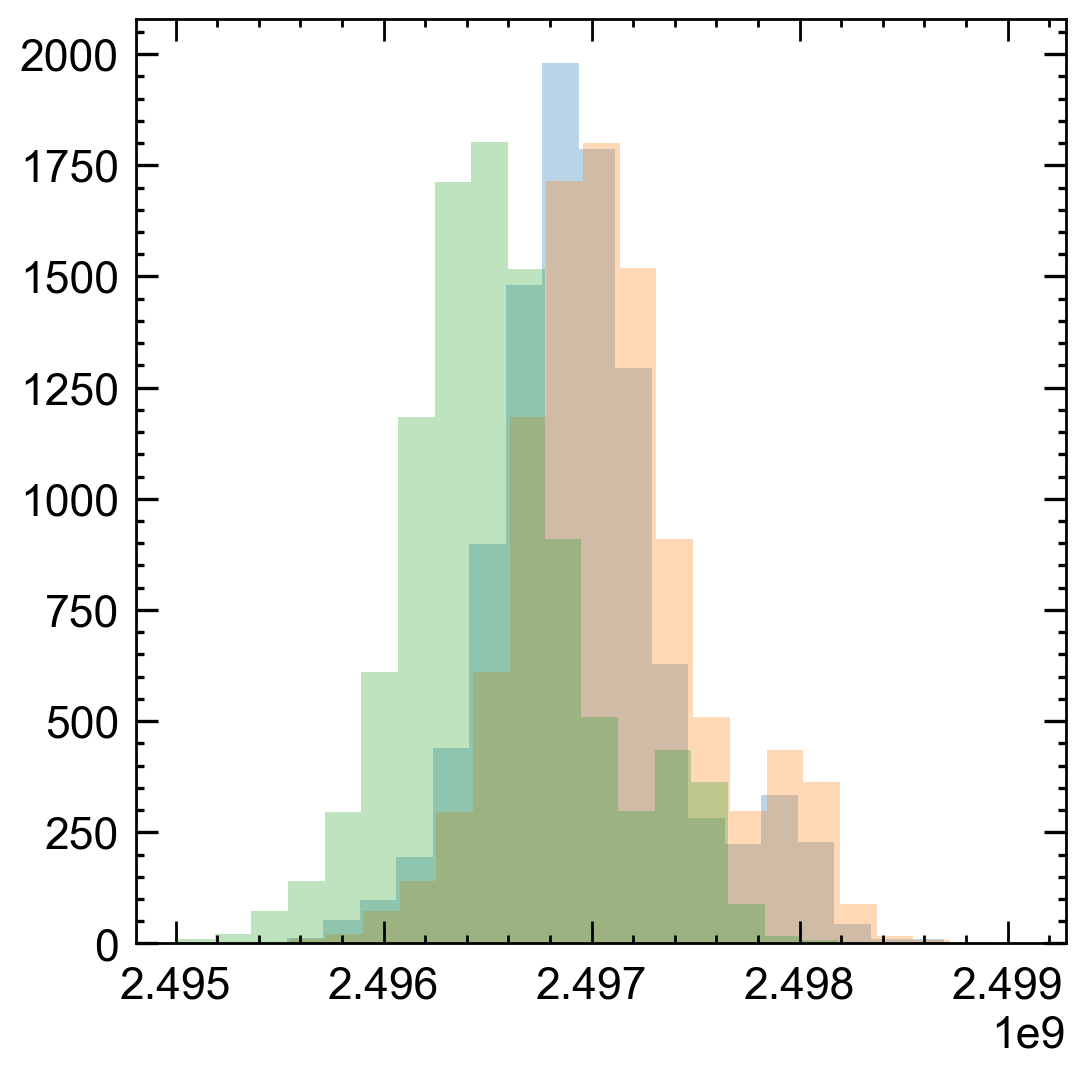

In [118]:
rp = np.array([g.r[0] for i, g in models_vary_ro['symmetric'].items()])
rn = np.array([g.r[0] for seed, g in models_vary_ro['composite'].items()])
rs = np.array([g.r[-1] for seed, g in models_vary_ro['composite'].items()])

plt.hist(rp, bins=20, alpha=0.3)
plt.hist(rn, bins=20, alpha=0.3)
plt.hist(rs, bins=20, alpha=0.3)

In [119]:
rp = np.array([g.r[0] for i, g in models_vary_ro['symmetric'].items()])
re = np.array([g.r[len(g.mu) // 2] for i, g in models_vary_ro['symmetric'].items()])
print('symmetric, vary R_occ')
print('rp: ', 1e-5 * np.mean(rp), '+/-', 1e-5 * np.std(rp))
print('re: ', 1e-5 * np.mean(re), '+/-', 1e-5 * np.std(re))

# symmetric, vary R_occ
# rp:  24967.925561198335 +/- 4.676707531151701
# re:  25556.57116435629 +/- 5.000391227000426


symmetric, vary R_occ
rp:  24969.62232758043 +/- 4.414666903308956
re:  25558.38536850928 +/- 4.7203374970962955


Text(0.5, 1.0, 'Composite fit')

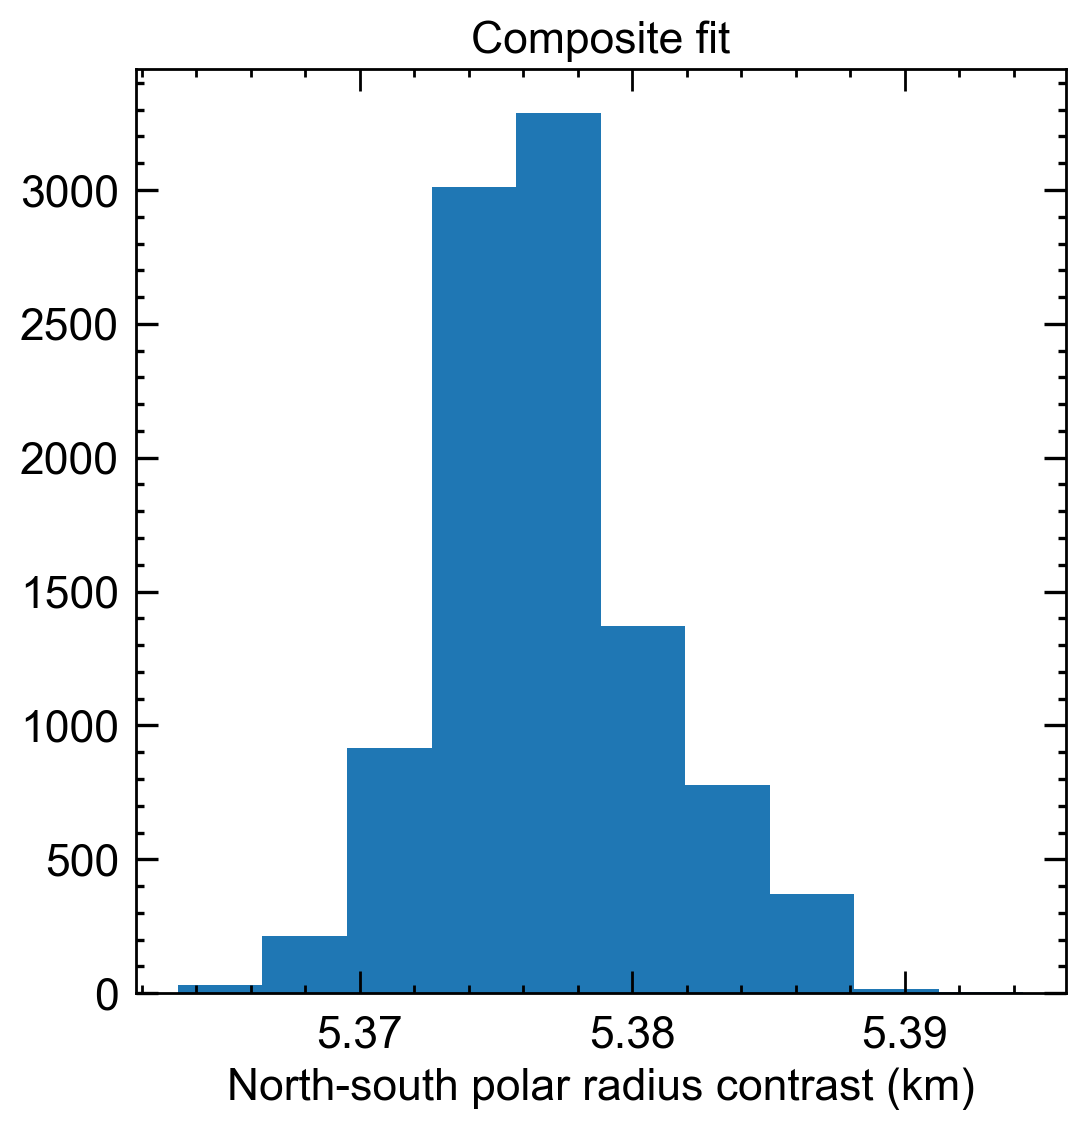

In [120]:
rn = np.array([g.r[0] for seed, g in models_vary_ro['composite'].items()])
rs = np.array([g.r[-1] for seed, g in models_vary_ro['composite'].items()])
plt.hist(1e-5 * (rn - rs))
plt.xlabel('North-south polar radius contrast (km)')
plt.title('Composite fit')

pole:
symmetric profile: $24969.6\pm4.4$ km
composite profile, north pole: $24971.0\pm4.6$ km
composite profile, south pole: $24965.6\pm4.6$ km

equator:
symmetric profile: $25558.4\pm4.7$ km
composite profile: $25558.7\pm4.9$ km


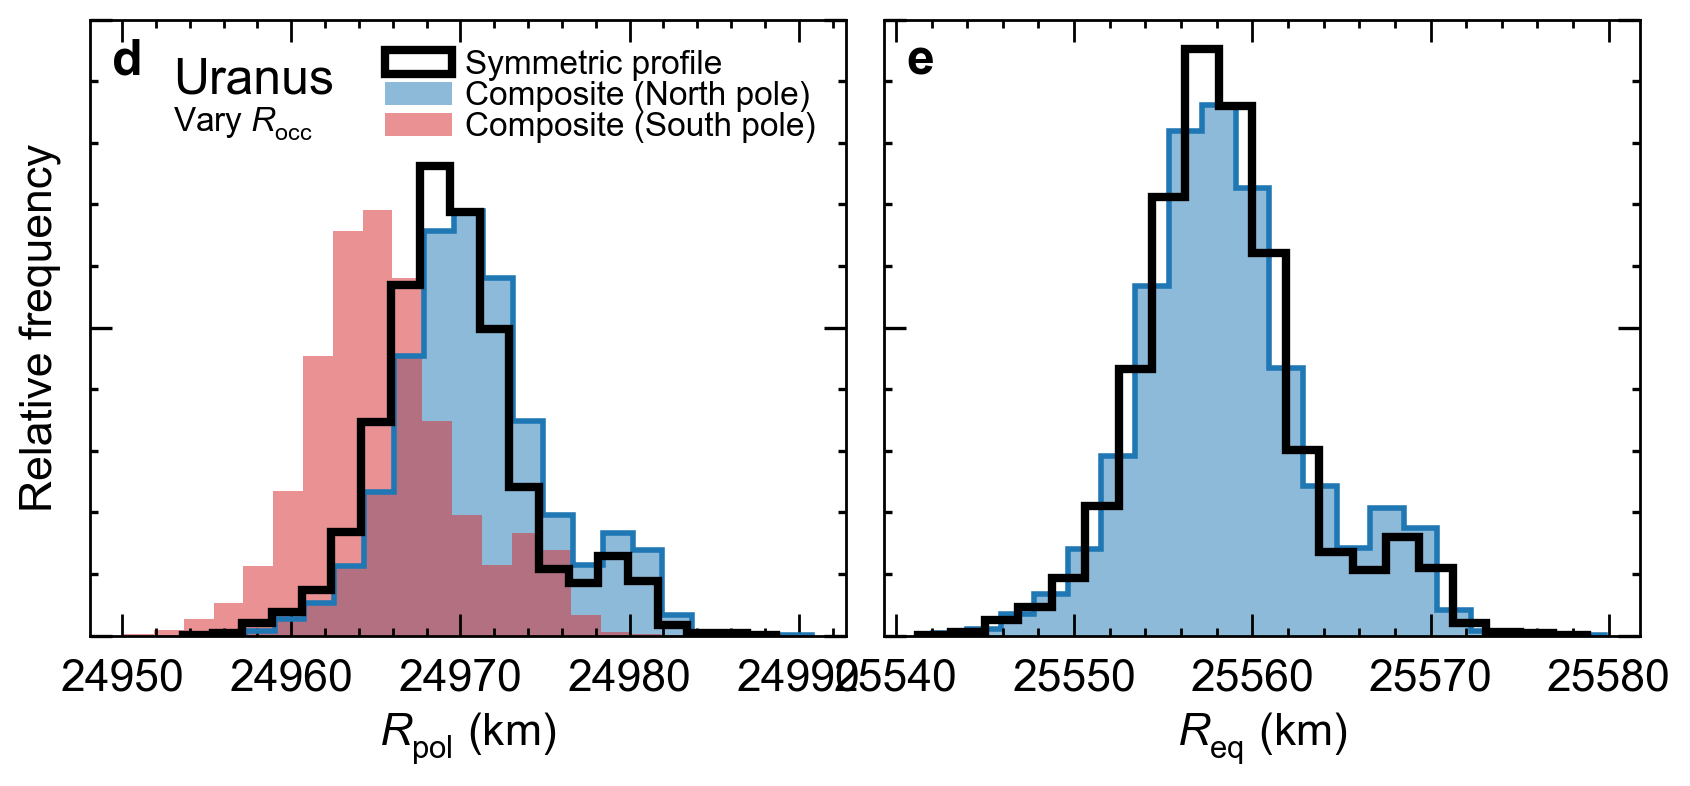

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})

rp = np.array([g.r[0] for seed, g in models_vary_ro['symmetric'].items()])
# plt.hist(1e-5 * rp - offset, alpha=0.2, density=True, color='k')
ax[0].hist(1e-5 * rp, density=True, color='k', histtype='step', lw=3, bins=20, label='Symmetric profile', zorder=5)
stats = rf'${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km'
print('pole:')
print('symmetric profile:', stats)
# plt.text(24975 - 0.1, 1.15, 'Symmetric\nprofile', ha='right', va='top', color='k')
# plt.text(24975 - 0.1, 1.02, stats, ha='right', va='top', color='k', fontsize=12)

rp_north = np.array([g.r[ 0] for seed, g in models_vary_ro['composite'].items()])
rp_south = np.array([g.r[-1] for seed, g in models_vary_ro['composite'].items()])
ax[0].hist(1e-5 * rp_north, density=True, color='tab:blue', histtype='stepfilled', alpha=0.5, bins=20, label='Composite (North pole)')
ax[0].hist(1e-5 * rp_north, density=True, histtype='step', bins=20, edgecolor='tab:blue', lw=2)
ax[0].hist(1e-5 * rp_south, density=True, color='tab:red' , histtype='stepfilled', alpha=0.5, bins=20, label='Composite (South pole)')
# ax[0].hist(1e-5 * rp_south, density=True, histtype='step', bins=20, edgecolor='tab:red', lw=3)
stats = rf'${np.mean(rp_north*1e-5):.1f}\pm{np.std(rp_north*1e-5):.1f}$ km'
print('composite profile, north pole:', stats)
stats = rf'${np.mean(rp_south*1e-5):.1f}\pm{np.std(rp_south*1e-5):.1f}$ km'
print('composite profile, south pole:', stats)
print()

print('equator:')
re = np.array([g.r[len(g.mu) // 2] for i, g in models_vary_ro['symmetric'].items()])
ax[1].hist(1e-5 * re, density=True, color='k', histtype='step', lw=3, bins=20, label='Symmetric profile')
stats = rf'${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km'
print('symmetric profile:', stats)

re = np.array([g.r[len(g.mu) // 2] for i, g in models_vary_ro['composite'].items()])
ax[1].hist(1e-5 * re, density=True, color='tab:blue', histtype='stepfilled', alpha=0.5, bins=20, label='Composite profile')
ax[1].hist(1e-5 * re, density=True, color='tab:blue', histtype='step', bins=20, lw=2, zorder=0)
stats = rf'${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km'
print('composite profile:', stats)


for iax, z in enumerate(ax):
    yl = np.array(z.get_ylim())
    if iax == 0: 
        yl *= 1.25
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=1)

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
# ax[0].set_xlim(23800, 24500)
# ax[1].set_xlim(24730, 24800)
ax[0].text(0.11, 0.88, 'Uranus', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.11, 0.82, r'Vary $R_{\rm occ}$', fontsize=12, transform=ax[0].transAxes)
for iax, c in enumerate('de'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/uranus_radii_vary_ro.pdf')

Text(0, 0.5, '$10^6\\,J_4$')

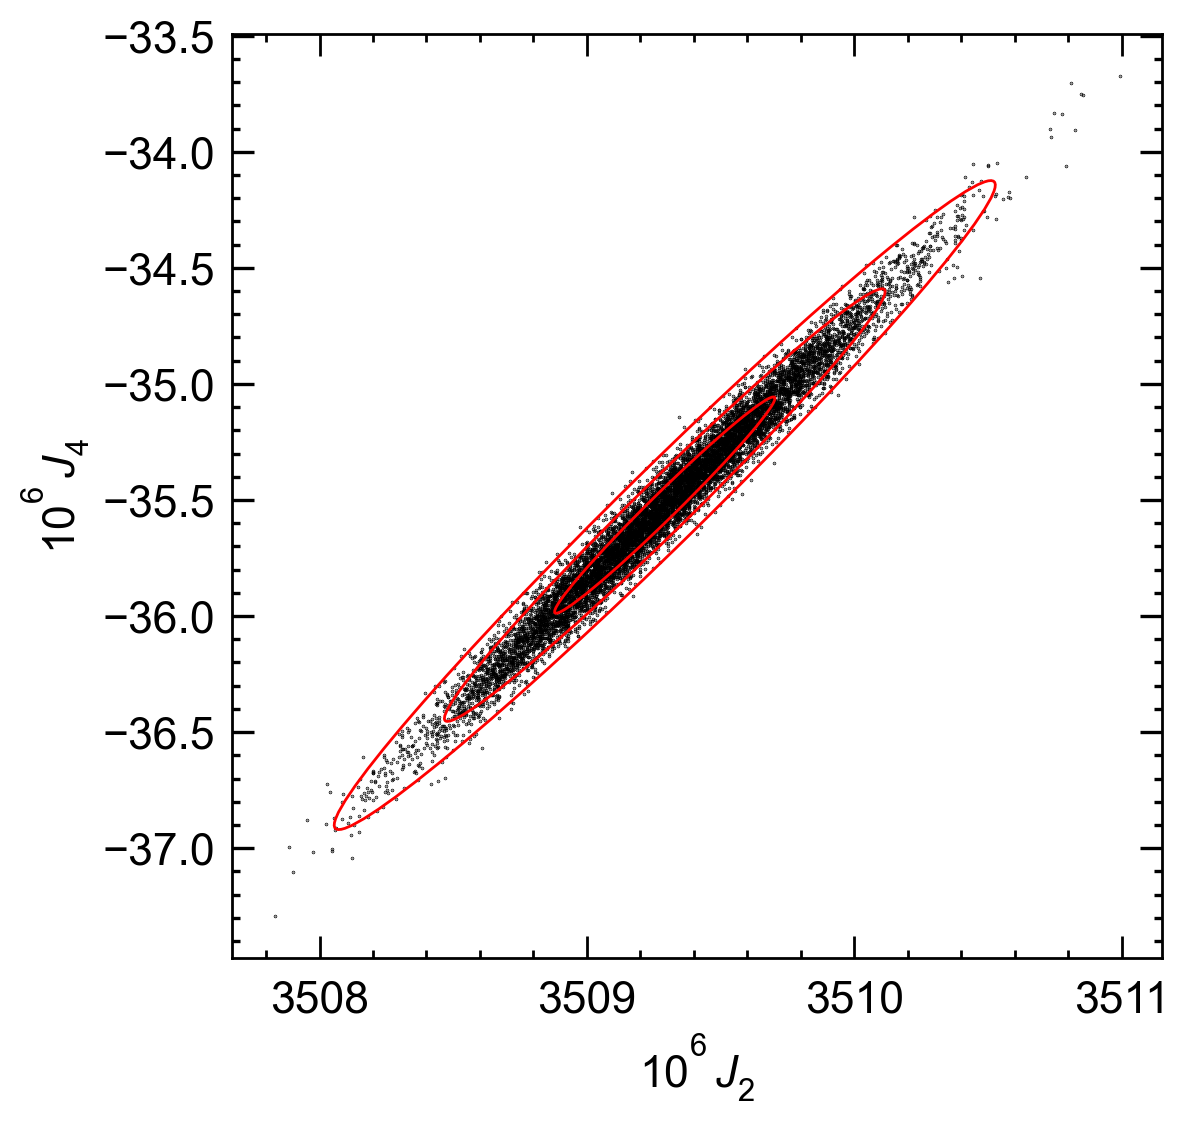

In [67]:
# French et al. 2024 Table 17: Uranus gravity parameters, Fit 15, Adopted solution
french_j2, french_dj2 = 3509.291e-6, 0.412e-6
french_j4, french_dj4 = -35.522e-6, 0.466e-6
correlation = 0.9861
# we can use French's relations to estimate j6 as a function of j2 and j4, or simply run it twice for end-member values of j6 (say 0 and 1e-6)

from scipy.stats import multivariate_normal
gauss_jn = multivariate_normal(
    mean=np.array([french_j2, french_j4]),
    cov=np.array([
        [french_dj2 ** 2, correlation * french_dj2 * french_dj4], 
        [correlation * french_dj2 * french_dj4, french_dj4 ** 2]
        ])
)

[plt.plot(1e6*pair[0], 1e6*pair[1], 'k.', ms=0.5) for pair in np.array([gauss_jn.rvs() for i in np.arange(10000)])];

def ellipse(ax, xmean, xscale, ymean, yscale, rho_xy, n_std=3, facecolor='tab:pink', edgecolor='tab:pink', **kwargs):
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    cov = np.array([[1., rho_xy], [rho_xy, 1.]])
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse(
        xy=(0, 0), 
        width=ell_radius_x * 2, 
        height=ell_radius_y * 2,
        facecolor=facecolor,
        edgecolor=edgecolor,
        **kwargs
        )

    scale_x = np.sqrt(cov[0, 0]) * xscale * n_std
    scale_y = np.sqrt(cov[1, 1]) * yscale * n_std
    mean_x = xmean
    mean_y = ymean

    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

ax = plt.gca()
ellipse(ax, xmean=1e6*french_j2, xscale=1e6*french_dj2, ymean=1e6*french_j4, yscale=1e6*french_dj4, rho_xy=correlation, n_std=3, edgecolor='r',  facecolor='none', zorder=2)
ellipse(ax, xmean=1e6*french_j2, xscale=1e6*french_dj2, ymean=1e6*french_j4, yscale=1e6*french_dj4, rho_xy=correlation, n_std=2, edgecolor='r',  facecolor='none', zorder=2)
ellipse(ax, xmean=1e6*french_j2, xscale=1e6*french_dj2, ymean=1e6*french_j4, yscale=1e6*french_dj4, rho_xy=correlation, n_std=1, edgecolor='r',  facecolor='none', zorder=2)
ax.set_xlabel(r'$10^6\,J_2$')
ax.set_ylabel(r'$10^6\,J_4$')

In [76]:
jn

(0.003509291, -3.5522e-05, 0.0)

In [101]:
j2, j4 = gauss_jn.rvs()

In [115]:
# finally vary jn
reload(geoid)
reload(wind_profiles)

omega_symmetric = wind_profiles.uranus_omega_tot_interpolant(option='symmetric')

def get_rmse_randomize_jn(x, omega, jn):
    r_pol = x * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

    squared_errors = np.array([ (_rocc - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for _occ, (_lat, _rocc) in occultation_radii.items()])
    return np.sqrt(np.mean(squared_errors))
    
def solve_one_vary_jn(omega):

    j2, j4 = gauss_jn.rvs()
    jn = j2, j4, 0.

    sol = minimize_scalar(get_rmse_randomize_jn, args=(omega, jn), bracket=np.array([2., 3.]), method='brent', options={'xtol':1e-6})
    assert sol.success, 'failed to fit occultations'
    # print(sol.nit, sol.nfev, f'{sol.fun:.1f}')
    r_pol = sol.x * 1e9

    # get final shape for optimized r_pol
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

    return g

np.random.seed(seed=2025)

from tqdm import tqdm
models_vary_jn = {}

# nmodels = 100
nmodels = 10000
models_vary_jn['symmetric'] = {}
for i in tqdm(np.arange(nmodels)):
    models_vary_jn['symmetric'][i] = solve_one_vary_jn(omega_symmetric)


100%|██████████| 10000/10000 [42:46<00:00,  3.90it/s]


symmetric profile: $24968.435\pm0.025$ km


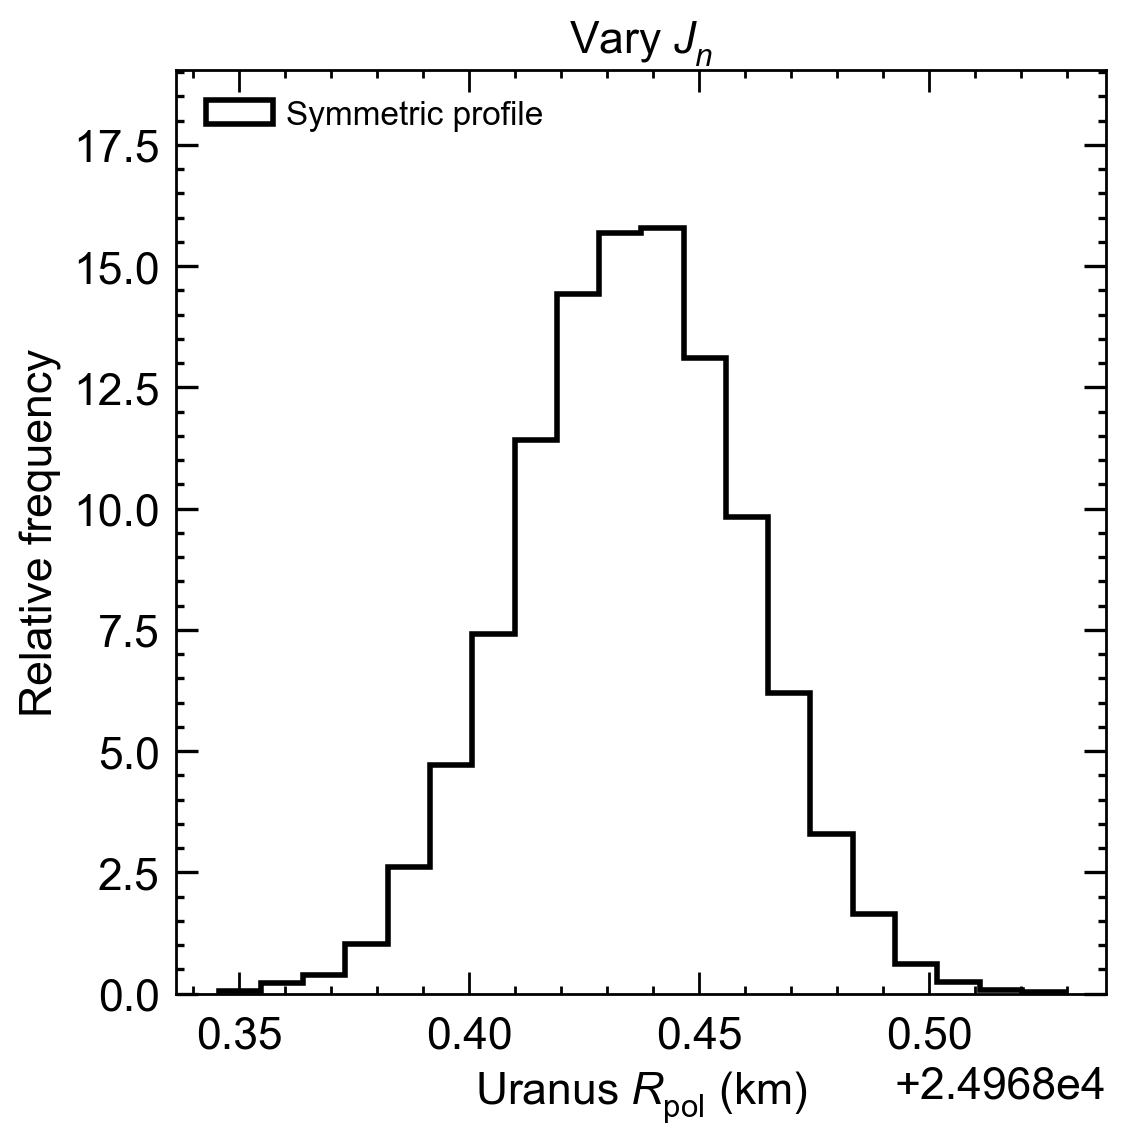

In [116]:
offset = 0

rp = np.array([g.r[0] for seed, g in models_vary_jn['symmetric'].items()])
# plt.hist(1e-5 * rp - offset, alpha=0.2, density=True, color='k')
plt.hist(1e-5 * rp - offset, density=True, color='k', histtype='step', lw=2, bins=20, label='Symmetric profile')
stats = rf'${np.mean(rp*1e-5):.3f}\pm{np.std(rp*1e-5):.3f}$ km'
print('symmetric profile:', stats)

plt.legend(loc=2, fontsize=12)

yl = np.array(plt.ylim())
yl[1] *= 1.15
plt.ylim(*yl)
plt.xlabel(r'Uranus $R_{\rm pol}$ (km)')
plt.ylabel(r'Relative frequency')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
# plt.gca().tick_params(labelleft=False)
# plt.xlim(24970, 24980)
plt.title(r'Vary $J_n$')

plt.savefig('figures/uranus_polar_radii_histogram_vary_rocc.pdf')

# 30-m standard deviation. improvements on Jn will not help constrain the shape.

In [ ]:
''' save everything '''

import pathlib
pathlib.Path('models/statistical_samples/uranus_vary_wind' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/uranus_vary_rocc' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/uranus_vary_jn'   ).mkdir(exist_ok=True, parents=True)

if True: # save all the models as pickled python dictionaries. for the several x10^4 models here this is ~6 GB. not the most interoperable but possibly convenient later.
    uranus_models = {
        'vary_wind' : models_vary_wind,
        'vary_ro'   : models_vary_ro,
        'vary_jn'   : models_vary_jn 
    }
    import dill as pickle
    with open('models/geoid_objects/uranus.pkl', 'wb') as fw:
        pickle.dump(uranus_models, fw)

if True: # save abridged set of full models.
    uranus_models = {
        'vary_wind' : models_vary_wind,
        'vary_ro'   : models_vary_ro,
        'vary_jn'   : models_vary_jn 
    }
    uranus_models_abridged = {}
    for experiment, models_this_experiment in uranus_models.items():
        uranus_models_abridged[experiment] = {}
        uranus_models_abridged[experiment]['symmetric'] = {}
        [uranus_models_abridged[experiment]['symmetric'].update({i: uranus_models[experiment]['symmetric'][i]}) for i in np.arange(128)]
        if 'composite' in list(uranus_models_abridged[experiment]):
            uranus_models_abridged[experiment]['composite'] = uranus_models[experiment]['composite']

    import dill as pickle
    with open('models/geoid_objects/uranus_abridged.pkl', 'wb') as fw:
        pickle.dump(uranus_models_abridged, fw)

if True: # save arrays of equatorial and polar radii, and ~tens of full models, to plaintext

    # tables of equatorial/polar radii
    outfile = 'models/statistical_samples/uranus_radii_symmetric_wind_vary_wind.txt'
    index = np.array([i for i, g in models_vary_wind['symmetric'].items()])
    rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_wind['symmetric'].items()])
    re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_wind['symmetric'].items()])
    header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'the distribution of models in this file comes from randomly drawing wind fit coefficients from Gaussians with means and standard deviations given by Sromovsky et al. Table 5 (Fit 1).\n'
    header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = ('%5i', '%16.8f', '%16.8f')
    np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

    outfile = 'models/statistical_samples/uranus_radii_symmetric_wind_vary_ro.txt'
    index = np.array([i for i, g in models_vary_ro['symmetric'].items()])
    rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_ro['symmetric'].items()])
    re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_ro['symmetric'].items()])
    header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'the distribution of models in this file comes from randomly drawing the near-equatorial occultation radius from a Gaussian with standard deviation equal to 5 km.\n'
    header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = ('%5i', '%16.8f', '%16.8f')
    np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

    outfile = 'models/statistical_samples/uranus_radii_symmetric_wind_vary_jn.txt'
    index = np.array([i for i, g in models_vary_jn['symmetric'].items()])
    rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_jn['symmetric'].items()])
    re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_jn['symmetric'].items()])
    header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models in this file assume the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'the distribution of models in this file comes from randomly drawing the gravity moments j2,j4 from a multivariate Gaussian from French et al. 2024 Table 17: Fit 15, Adopted solution.\n'
    header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = ('%5i', '%16.8f', '%16.8f')
    np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

    outfile = 'models/statistical_samples/uranus_radii_composite_wind_vary_ro.txt'
    index = np.array([i for i, g in models_vary_ro['composite'].items()])
    rp_km = np.array([1e-5 * g.r[0] for i, g in models_vary_ro['composite'].items()])
    re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for i, g in models_vary_ro['composite'].items()])
    header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models in this file assume the composite wind profile from Sromovsky et al. (2015, Icarus 258) Table 6.\n'
    header += 'the distribution of models in this file comes from randomly drawing the near-equatorial occultation radius from a Gaussian with standard deviation equal to 5 km.\n'
    header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = ('%5i', '%16.8f', '%16.8f')
    np.savetxt(outfile, np.array([index, rp_km, re_km]).T, fmt=fmt, header=header, comments='')

    # save main Uranus shape model, once for symmetric wind and once for composite wind
    g = g_baseline
    outfile = 'models/uranus_model_symmetric_wind.txt'
    header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degress] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = models_vary_wind['composite']
    outfile = 'models/uranus_model_composite_wind.txt'
    header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the composite wind profile from Sromovsky et al. (2015, Icarus 258) Table 6.\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degress] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    # detailed model output saved to plaintext for a small number of models
    n_models_each_type = 32
    for i in np.arange(n_models_each_type):
        g = models_vary_wind['symmetric'][i]
        outfile = f'models/statistical_samples/uranus_vary_wind/uranus_symmetric_wind_vary_wind_{i:02}.txt'
        header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
        header += 'the adopted profiles of the drift rate come from coefficients randomly drawn as Gaussians with standard deviations equal to Unc. in Table 5 (Fit 1).\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.10f'
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    for i in np.arange(n_models_each_type):
        g = models_vary_ro['symmetric'][i]
        outfile = f'models/statistical_samples/uranus_vary_rocc/uranus_symmetric_wind_varyrocc{i:02}.txt'
        header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
        header += 'target occultation radius (Voyager 2 ingress) was randomly sampled as a Gaussian with a 5 km standard deviation.\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.10f'
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    for i in np.arange(n_models_each_type):
        g = models_vary_jn['symmetric'][i]
        outfile = f'models/statistical_samples/uranus_vary_jn/uranus_symmetric_wind_varyjn{i:02}.txt'
        header  = "detailed model output for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
        header += 'this model assumes the symmetric wind profile from Sromovsky et al. (2015, Icarus 258) Equation (2).\n'
        header += 'input j2 and j4 were randomly sampled from a bivariate Gaussian with uncertainties given by French et al. 2024 Table 17: Fit 15, Adopted solution.\n'
        header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
        # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
        fmt = '%16.10f'
        names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
        for name in names:
            header += f"{name:>16} "
        data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
        np.savetxt(outfile, data, fmt=fmt, header=header, comments='')
